<a href="https://colab.research.google.com/github/saltatt/Forecast-projects/blob/main/cafe_profit_forecast_withPWBI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cafe Profit Forecast: Sep–Dec 2026
Cafe kiosk inside a baby swimming studio (customers: parents + studio staff). Only **August 2026** of real data exists, so this notebook uses a transparent **scenario + Monte Carlo** model instead of a black-box ML model (19 recorded days are too few to train one honestly).

**Question:** after 4 months, will monthly profit rise or fall vs August?

**How it works**
1. Load August daily sales (day-of-week pattern, share of days above the 20k KZT target).
2. Apply month-by-month **seasonal demand multipliers** and **margin (COGS) rates** (hot drinks replace iced drinks/milkshakes in autumn).
3. Simulate 5,000 possible months per scenario → probability that profit is higher than August.
4. Export CSVs for Power BI.

> ⚠️ Seasonal multipliers are **assumptions** (editable in the `SEASON` table). Replace them with real data as each new month arrives.

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
np.random.seed(42)
pd.set_option('display.float_format', '{:,.0f}'.format)

## 1. August 2026 data (KZT)
Day 1 = Sat 1 Aug 2026. `None` = not recorded (days 1, 14, 19–21, 25–31).

In [ ]:
sales = {2:13000,3:6000,4:14000,5:9000,6:14500,7:14000,8:14000,9:6000,10:21000,
         11:6000,12:8100,13:17000,15:17000,16:16000,17:18000,18:8000,22:21000,23:23000,24:18000}
days = pd.date_range('2026-08-01','2026-08-31')
daily = pd.DataFrame({'date':days})
daily['revenue'] = daily.date.dt.day.map(sales)
daily['weekday'] = daily.date.dt.day_name()
daily['recorded'] = daily.revenue.notna()
obs = daily.dropna()
print('Recorded days:', len(obs), '| avg/day:', round(obs.revenue.mean()), '| median:', obs.revenue.median())
print('Days >= 20k target: %d of %d' % ((obs.revenue>=20000).sum(), len(obs)))
obs.groupby('weekday').revenue.agg(['count','mean']).sort_values('mean', ascending=False)

Recorded days: 19 | avg/day: 13874 | median: 14000.0
Days >= 20k target: 3 of 19


,count,mean
weekday,,
Saturday,3,"17,333"
Monday,4,"15,750"
Thursday,2,"15,750"
Sunday,4,"14,500"
Friday,1,"14,000"
Tuesday,3,"9,333"
Wednesday,2,"8,550"


## 2. Business parameters

In [ ]:
RENT = 110_000          # per month
BARISTA = 65_000        # per month
OTHER_FIXED = 0         # utilities, phone, etc. (edit if any)
PURCHASE = 300_000      # cafe purchase (one-off)
FURNITURE = 143_000     # chairs + trays (one-off)
TARGET_DAILY = 20_000   # daily sales needed to be 'sufficient'
FIXED = RENT + BARISTA + OTHER_FIXED
print('Fixed costs/month:', FIXED, '| fixed per day:', round(FIXED/31))

Fixed costs/month: 175000 | fixed per day: 5645


## 3. Seasonal assumptions
Reasoning (Kazakhstan, indoor kids' activity venue):
- **Aug:** hot, many families on holiday → weaker attendance; buyers choose iced coffee, lemonade, milkshakes, cold bottled drinks (low margin, bought at retail from Magnum).
- **Sep–Oct:** kids' classes restart after summer, swimming enrolment peaks → more parents waiting on-site; demand for latte/cappuccino, tea (karak chai), hot chocolate, pastries.
- **Nov:** cold weather, hot drinks + pastries dominate; stable attendance.
- **Dec:** strong hot-drink demand, but holidays/illness reduce attendance in the last 2 weeks.

`demand` = multiplier on August average sales. `cogs` = share of revenue spent on ingredients/purchased goods (**assumption**; compute your real one from receipts). `sd` = uncertainty of the multiplier.

In [ ]:
SEASON = pd.DataFrame({
 'month':['Aug','Sep','Oct','Nov','Dec'],
 'month_num':[8,9,10,11,12],
 'days':[31,30,31,30,31],
 'demand':[1.00,1.10,1.15,1.10,1.05],
 'cogs':[0.48,0.45,0.42,0.42,0.43],
 'sd':[0.00,0.12,0.12,0.14,0.16],
 'top_products':['iced coffee, lemonade, milkshake, cold drinks, ice cream',
                 'latte, cappuccino, karak chai, pastries, cold drinks fading',
                 'hot coffee, karak chai, hot chocolate, pastries, baursak',
                 'hot drinks, tea, pastries, cakes/pies',
                 'hot drinks, hot chocolate, cakes, holiday sweets']})
SEASON

,month,month_num,days,demand,cogs,sd,top_products
0,Aug,8,31,1,0,0,"iced coffee, lemonade, milkshake, cold drinks,..."
1,Sep,9,30,1,0,0,"latte, cappuccino, karak chai, pastries, cold ..."
2,Oct,10,31,1,0,0,"hot coffee, karak chai, hot chocolate, pastrie..."
3,Nov,11,30,1,0,0,"hot drinks, tea, pastries, cakes/pies"
4,Dec,12,31,1,0,0,"hot drinks, hot chocolate, cakes, holiday sweets"


## 4. Monte Carlo simulation
Each simulated day = random August daily sale (bootstrap) × month multiplier (random around `demand`).
Scenarios shift the multiplier: **pessimistic** ×0.85, **base** ×1.00, **optimistic** ×1.15.

In [ ]:
SCEN = {'pessimistic':0.85,'base':1.00,'optimistic':1.15}
N = 5000
pool = obs.revenue.values

def simulate(row, scen_factor):
    out=[]
    for _ in range(N):
        m = max(0.3, np.random.normal(row.demand*scen_factor, row.sd))
        rev = np.random.choice(pool, row.days).sum()*m
        profit = rev*(1-row.cogs) - FIXED
        out.append((rev, profit))
    return np.array(out)

rows=[]; sims={}
for s,f in SCEN.items():
    for _,r in SEASON.iterrows():
        a = simulate(r, f if r.month!='Aug' else 1.0)
        sims[(s,r.month)] = a
        rows.append(dict(scenario=s, month=r.month, month_num=r.month_num,
            revenue=a[:,0].mean(), profit=a[:,1].mean(),
            profit_p10=np.percentile(a[:,1],10), profit_p90=np.percentile(a[:,1],90),
            avg_daily_sales=a[:,0].mean()/r.days))
fc = pd.DataFrame(rows)
aug_profit = fc[(fc.scenario=='base')&(fc.month=='Aug')].profit.iloc[0]
fc['vs_aug'] = fc.profit - aug_profit
fc['prob_beats_aug'] = [ (sims[(s,m)][:,1] > aug_profit).mean() for s,m in zip(fc.scenario, fc.month)]
print('August profit (extrapolated to 31 days): %s KZT' % f'{aug_profit:,.0f}')
fc.pivot(index='month', columns='scenario', values='profit').loc[['Aug','Sep','Oct','Nov','Dec']]

August profit (extrapolated to 31 days): 49,011 KZT


scenario,base,optimistic,pessimistic
month,,,
Aug,"49,011","48,600","48,631"
Sep,"76,495","116,017","38,803"
Oct,"111,983","155,322","69,172"
Nov,"90,080","129,380","50,764"
Dec,"82,332","122,166","43,359"


## 5. Answer: will profit rise or fall after 4 months (December)?

In [ ]:
dec = fc[fc.month=='Dec'].set_index('scenario')
for s in SCEN:
    d = dec.loc[s]
    print(f"{s:12s} Dec profit {d.profit:>10,.0f} KZT | vs Aug {d.vs_aug:>+10,.0f} | P(higher than Aug) = {d.prob_beats_aug:.0%}")
verdict = 'RISE' if dec.loc['base','vs_aug']>0 else 'FALL'
print('\nBase-case verdict: profit is expected to', verdict, 'by December.')
be = FIXED/(1-SEASON.set_index('month').loc['Dec','cogs'])/31
print(f'Break-even daily sales in Dec: {be:,.0f} KZT | target: {TARGET_DAILY:,}')

pessimistic  Dec profit     43,359 KZT | vs Aug     -5,652 | P(higher than Aug) = 44%
base         Dec profit     82,332 KZT | vs Aug    +33,321 | P(higher than Aug) = 78%
optimistic   Dec profit    122,166 KZT | vs Aug    +73,156 | P(higher than Aug) = 96%

Base-case verdict: profit is expected to RISE by December.
Break-even daily sales in Dec: 9,904 KZT | target: 20,000


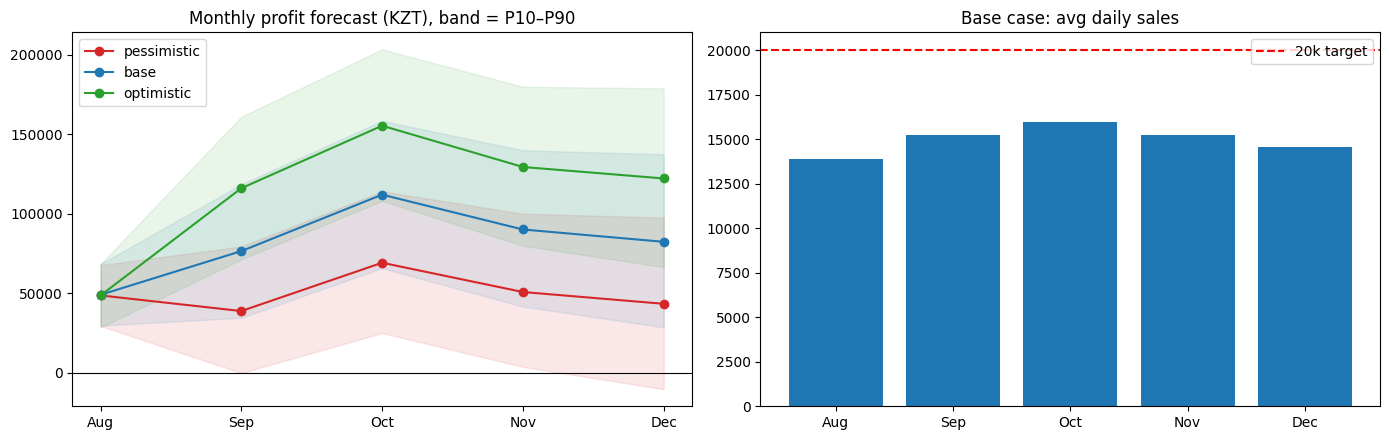

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(14,4.5))
order=['Aug','Sep','Oct','Nov','Dec']
for s,c in zip(SCEN,['tab:red','tab:blue','tab:green']):
    d = fc[fc.scenario==s].set_index('month').loc[order]
    ax[0].plot(order, d.profit, marker='o', label=s, color=c)
    ax[0].fill_between(order, d.profit_p10, d.profit_p90, alpha=0.1, color=c)
ax[0].axhline(0,color='k',lw=.8); ax[0].set_title('Monthly profit forecast (KZT), band = P10–P90'); ax[0].legend()
d = fc[fc.scenario=='base'].set_index('month').loc[order]
ax[1].bar(order, d.avg_daily_sales); ax[1].axhline(TARGET_DAILY, color='r', ls='--', label='20k target')
ax[1].set_title('Base case: avg daily sales'); ax[1].legend()
plt.tight_layout(); plt.show()

## 6. Payback of the investment

In [ ]:
INVEST = PURCHASE + FURNITURE
for s in SCEN:
    total = fc[(fc.scenario==s)&(fc.month!='Aug')].profit.sum()
    print(f'{s:12s} Sep–Dec cumulative profit: {total:>10,.0f} KZT  | avg/month {total/4:>9,.0f} | payback of {INVEST:,}: ',
          ('%.1f months' % (INVEST/(total/4))) if total>0 else 'not reached')

pessimistic  Sep–Dec cumulative profit:    202,099 KZT  | avg/month    50,525 | payback of 443,000:  8.8 months
base         Sep–Dec cumulative profit:    360,890 KZT  | avg/month    90,222 | payback of 443,000:  4.9 months
optimistic   Sep–Dec cumulative profit:    522,885 KZT  | avg/month   130,721 | payback of 443,000:  3.4 months


## 7. Export for Power BI

In [ ]:
daily.to_csv('daily_actuals.csv', index=False)
fc.to_csv('monthly_forecast.csv', index=False)
SEASON.to_csv('seasonal_assumptions.csv', index=False)
print('Saved: daily_actuals.csv, monthly_forecast.csv, seasonal_assumptions.csv')
try:
    from google.colab import files
    for f in ['daily_actuals.csv','monthly_forecast.csv','seasonal_assumptions.csv']: files.download(f)
except ImportError:
    pass

Saved: daily_actuals.csv, monthly_forecast.csv, seasonal_assumptions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Improving the model
- Add real COGS from receipts (the expense list mixes stock and one-off items).
- Record **every** day incl. zeros, plus number of receipts (traffic vs average check).
- After each month, update `demand` with actual results; after ~3 months try a regression with weekday + month.
- Track swimming-studio class schedule/enrolment as a driver (parents = your customers).